In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulating high-frequency data
# np.random.seed(100)
num_ticks = 1000  # Number of ticks to simulate
tick_data_samples = []
for i in range(1_000):  # Generate 10 samples
    price_changes = np.random.normal(loc=0, scale=0.01, size=num_ticks)
    prices = 100 * np.exp(np.cumsum(price_changes))  # Starting price of 100

    # Simulate bid and ask prices around the mid price
    bid_prices = prices - np.random.uniform(0.01, 0.05, size=num_ticks)
    ask_prices = prices + np.random.uniform(0.01, 0.05, size=num_ticks)
    bid_volumes = np.random.randint(1, 10, size=num_ticks)
    ask_volumes = np.random.randint(1, 10, size=num_ticks)

    # Create a DataFrame for the simulated tick data
    tick_data = pd.DataFrame({
        'Time': pd.date_range(start='2023-01-01', periods=num_ticks, freq='S'),  # 1-second intervals
        'Bid_Price': bid_prices,
        'Ask_Price': ask_prices,
        'Bid_Volume': bid_volumes,
        'Ask_Volume': ask_volumes
    })
    tick_data_samples.append(tick_data)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_27718/970828394.py:21: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  'Time': pd.date_range(start='2023-01-01', periods=num_ticks, freq='S'),  # 1-second intervals


In [201]:
class OBIVWAPStrategy:
    def __init__(self, vwap_window, obi_threshold, initial_cash=10000):
        self.vwap_window = vwap_window
        self.obi_threshold = obi_threshold
        self.cash = initial_cash
        self.position = 0
        self.account_balance = []

    def calculate_vwap(self, data):
        data['Mid_Price'] = (data['Bid_Price'] + data['Ask_Price']) / 2
        data['Volume'] = data['Bid_Volume'] + data['Ask_Volume']
        data['VWAP'] = (data['Mid_Price'] * data['Volume']).rolling(window=self.vwap_window).sum() / data['Volume'].rolling(window=self.vwap_window).sum()
        return data

    def calculate_obi(self, data):
        data['OBI'] = (data['Bid_Volume'] - data['Ask_Volume']) / (data['Bid_Volume'] + data['Ask_Volume'])
        return data

    def generate_signals(self, data):
        data = self.calculate_vwap(data)
        data = self.calculate_obi(data)
        data.dropna(inplace=True)
        data['Signal'] = 0
        data['Signal'][(data['OBI'] > self.obi_threshold)] = 1  # Buy signal
        data['Signal'][(data['OBI'] < -self.obi_threshold)] = -1  # Sell signal
        # data['Signal'][(data['OBI'] > self.obi_threshold) & (data['Mid_Price'] < data['VWAP'])] = 1  # Buy signal
        # data['Signal'][(data['OBI'] < -self.obi_threshold) & (data['Mid_Price'] > data['VWAP'])] = -1  # Sell signal
        return data

    def backtest(self, data):
        for index, row in data.iterrows():
            if row['Signal'] == 1 and self.cash > row['Ask_Price']:
                # Buy
                self.position += 1
                self.cash -= row['Ask_Price']
            elif row['Signal'] == -1 and self.position > 0:
                # Sell
                self.position -= 1
                self.cash += row['Bid_Price']
            # Record the account balance
            self.account_balance.append(self.cash + self.position * row['Mid_Price'])

        data['Account_Balance'] = self.account_balance
        return data

# Parameters for the strategy
vwap_window = 50
obi_threshold = 0.3

backtest_results = []

for tick_data in tick_data_samples:
    # instantiate the strategy with the parameters
    strategy = OBIVWAPStrategy(vwap_window, obi_threshold)
    signal_data = strategy.generate_signals(tick_data.copy())
    backtest_data = strategy.backtest(signal_data)
    backtest_results.append(backtest_data)

/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth0000gn/T/ipykernel_27718/1903999494.py:24: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  data['Signal'][(data['OBI'] > self.obi_threshold)] = 1  # Buy signal
/var/folders/h2/r7qn2m9n1zb6y_0q191gdqth000

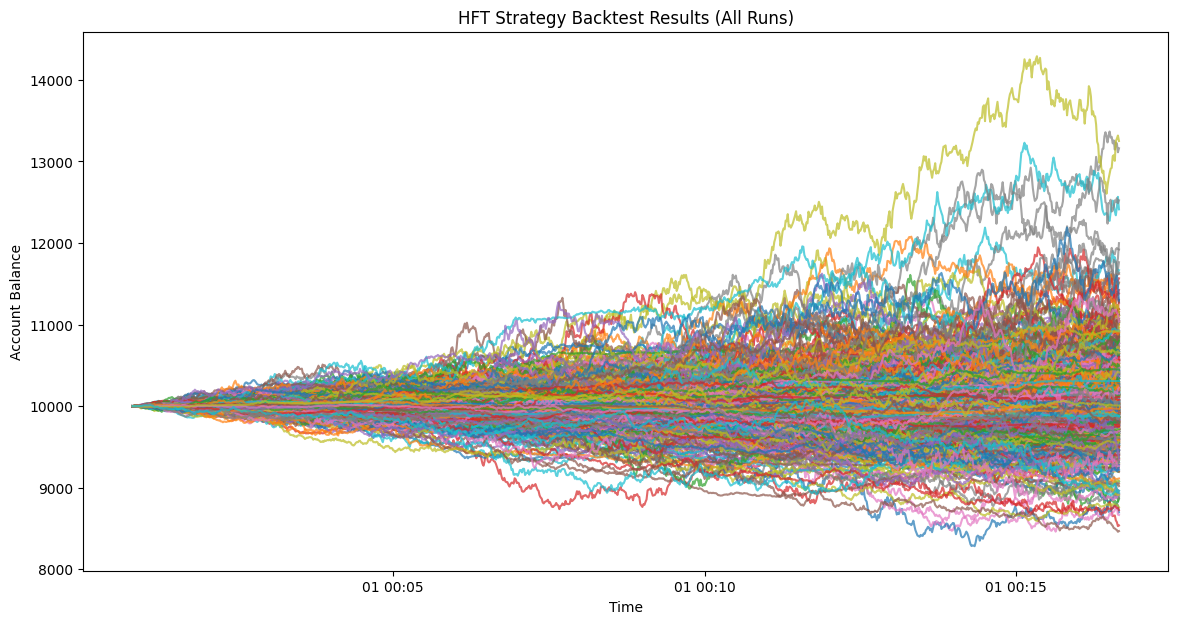

In [202]:
plt.figure(figsize=(14, 7))
for idx, result in enumerate(backtest_results):
    plt.plot(result['Time'], result['Account_Balance'], label=f'Run {idx+1}', alpha=0.7)
plt.title('HFT Strategy Backtest Results (All Runs)')
plt.xlabel('Time')
plt.ylabel('Account Balance')
plt.show()